### Model Evaluation Techniques for Multiple Linear Regression (MLR)

**Why Model Evaluation?**

* Model evaluation helps us measure how well our regression model predicts the target variable.
* Even if the model looks good, we need metrics to assess **accuracy**, **error**, and **explanatory power**.

### Common Evaluation Metrics for MLR

### 1. $R^2$ Score (Coefficient of Determination)

**Concept:**

* $R^2$ tells us what percentage of the variation in the target variable is explained by the model.

**$R^2$ Formula:**

$$R^2 = 1 - \frac{\sum(y_i - \hat{y}_i)^2}{\sum(y_i - \bar{y})^2}$$

* $y_i$: Actual value
* $\hat{y}_i$: Predicted value

* $\bar{y}$: Mean of actual values

#### Mean of Actual Values:

$$\bar{y} = \frac{10 + 15 + 18}{3} = 14.33$$

#### $\text{SS}_{\text{res}}$ (Sum of Squared Residuals):

$$(10 - 12)^2 + (15 - 14)^2 + (18 - 16)^2 = 4 + 1 + 4 = 9$$

#### $\text{SS}_{\text{total}}$ (Total Sum of Squares):

$$(10 - 14.33)^2 + (15 - 14.33)^2 + (18 - 14.33)^2 \approx 18.78 + 0.44 + 13.44 = 32.66$$


### $R^2$ Calculation:

$$R^2 = 1 - \frac{SS_{res}}{SS_{total}} = 1 - \frac{9}{32.66} \approx 0.7245$$

---

### Python Code:

In [1]:
from sklearn.metrics import r2_score

actual = [10, 15, 18]
pred = [12, 14, 16]
print("R²:", r2_score(actual, pred))

R²: 0.7244897959183674


### 2. RMSE (Root Mean Squared Error)

**RMSE Formula:**

$$\text{RMSE} = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2}$$

**Where:**

* $y_i$: Actual value
* $\hat{y}_i$: Predicted value
* $n$: Number of observations

---

### Example: RMSE Calculation


* Actual values: $[10, 15, 18]$
* Predicted values: $[12, 14, 16]$

We already calculated the sum of squared errors:

$$\text{MSE} = \frac{(10 - 12)^2 + (15 - 14)^2 + (18 - 16)^2}{3} = \frac{9}{3} = 3$$

Now calculate RMSE:

$$\text{RMSE} = \sqrt{3} \approx 1.732$$

In [4]:
from sklearn.metrics import mean_squared_error
import numpy as np

actual =[10, 15, 18]
pred = [ 12,14, 16]

rmse = np.sqrt(mean_squared_error(actual, pred))
print("RMSE:", round(rmse, 3))

RMSE: 1.732


### Example: MAE (Mean Absolute Error)

Let’s continue with the same example:

* Actual values: $[10, 15, 18]$
* Predicted values: $[12, 14, 16]$

Calculate absolute errors:

* $\vert{}10 - 12\vert{} = 2$
* $\vert{}15 - 14\vert{} = 1$
* $\vert{}18 - 16\vert{} = 2$

Now compute MAE:

$$\text{MAE} = \frac{2 + 1 + 2}{3} = \frac{5}{3} \approx 1.67$$

In [5]:
from sklearn.metrics import mean_absolute_error

actual =[10, 15, 18]
pred = [ 12,14, 16]

mae = mean_absolute_error(actual, pred)
print("MAE:", round(mae, 2))

MAE: 1.67


### Interpretation MAE $\approx 1.67$

* On average, predictions are 1.67 units off from actual values.

---

### Example: MAPE (Mean Absolute Percentage Error)

Same data:

* Actual: $[10, 15, 18]$
* Predicted: $[12, 14, 16]$

Step-by-step percentage errors:

$$\left\vert{}\frac{10 - 12}{10}\right\vert{} = 0.20$$

$$\left\vert{}\frac{15 - 14}{15}\right\vert{}= 0.0667$$

$$\left\vert{}\frac{18 - 16}{18}\right\vert{}= 0.1111$$

$$\text{MAPE} = \frac{0.20 + 0.0667 + 0.1111}{3} \times 100 \approx 12.59\%$$


In [7]:
actual = np.array([10, 15, 18])
pred = np.array([12, 14, 16])

mape = np.mean(np.abs((actual - pred)/ actual)) * 100
print("MAPE:", round(mape, 2), "%")

MAPE: 12.59 %


### Summary Table

| Metric | What it Measures | Ideal Value | Use Case |
| --- | --- | --- | --- |
| **$R^2$** | % variance explained | Closer to 1 | Model fit quality |
| **RMSE** | Average squared error | Closer to 0 | Penalizes large errors |
| **MAE** | Average absolute error | Closer to 0 | Simpler error interpretation |
| **MAPE** | Avg % error from actuals | Lower % | Explaining % error to audience |

### Final Notes:

* Always evaluate the model on **test data**
* Use **multiple metrics** to get a complete picture
* RMSE penalizes large errors more; MAE is easier to explain
* $R^2$ shows explanatory power, not accuracy

Use these metrics to select and justify your regression model before making business decisions or deployment.


### Python Code: Model Evaluation on Test Data

```python
mse_test = mean_squared_error(y_test, y_test_pred)
r2_test = r2_score(y_test, y_test_pred)

print(f'Multiple Linear Regression - Testing MSE: {mse_test}, Testing R2: {r2_test}')

```
### Output Result:

```text
Multiple Linear Regression - Testing MSE: 2.5416240362291487, Testing R2: 0.9091484341849799

```

### What is a Residual Plot?

* A residual is the difference between the actual value and the predicted value.

#### Residual Formula

$$\text{Residual} = y_{\text{actual}} - y_{\text{predicted}}$$

A residual plot is a graph that shows:

* **x-axis** $\rightarrow$ predicted values
* **y-axis** $\rightarrow$ residuals (errors)

### What Does a Good Residual Plot Look Like?

* Residuals should be randomly scattered around the horizontal line at 0.
* No clear pattern should be visible.
* This means: your model's errors are evenly distributed $\rightarrow$ a sign of a good fit.

---

### Why It's Important

If your residuals do not look random:

* You may have missed a pattern in the data.
* If residuals increase/decrease systematically, it may mean:

* missing nonlinear relationship.
* model may be underfitting or overfitting.

### If Residuals Show a Systematic Pattern...

**What It Indicates:**

* A clear curve, slope, or funnel shape in the residuals means your model is violating key assumptions of linear regression – especially linearity and homoscedasticity (constant variance).

This usually points to:

* A nonlinear relationship that linear regression can't capture
* Missing variables or interactions in the model
* Possible underfitting

### What You Can Do to Fix It

#### 1. Add Polynomial Terms

* If the residuals follow a curved pattern (U-shape or inverted U), it means the relationship is nonlinear.
* **Fix**: Try a Polynomial Regression model

```python
# from sklearn.preprocessing import PolynomialFeatures
# from sklearn.linear_model import LinearRegression
# from sklearn.pipeline import make_pipeline

# poly_model = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())
# poly_model.fit(X_train, y_train)

```

#### 2. Apply Feature Transformation

* If residuals increase or decrease systematically, apply transformations like:
* Log or sqrt for right-skewed variables
* Box-Cox for automatic transformation (scipy)

### 3. Add Missing Features or Interaction Terms

* Sometimes the model misses important variables or their interactions.
* **Fix**: Add interaction manually

### 4. Use a More Flexible Model

* If linear regression is still struggling:
* Try Decision Trees, Random Forests, or Gradient Boosting
* These handle nonlinearities and interactions automatically

```python
#df['log_variable'] = np.log(df['original_variable'] + 1)

```

### Note

* If your residuals show a curved pattern or increase with predictions, your model is likely missing something.
* You can fix this by adding polynomial terms, transforming variables, or switching to a nonlinear model.
* Residual plots aren't just diagnostic — they guide how to improve the model.

---

### If Residuals Suggest Underfitting or Overfitting

Here’s how to detect and fix each:

### Underfitting

**Clues:**

* Residuals show clear pattern (e.g., curve, slope)
* $R^2$ is low on both training and test sets
* Model is too simple to capture true data structure

**Common Causes:**

* Using only linear terms when the relationship is nonlinear
* Leaving out important features

**Remedies:**

* Add polynomial features (e.g., degree 2 or 3)
* Include interaction terms
* Apply log/sqrt transformations
* Switch to a more complex model (e.g., decision tree)

### Overfitting

**Clues:**

* Residuals look random on training data, but prediction errors are high on test data
* High $R^2$ on training, low $R^2$ on test
* Too many predictors or overly complex model

**Common Causes:**

* Model memorizes noise instead of generalizing patterns

**Remedies:**

* Simplify the model (remove unnecessary features)
* Use regularization: Ridge or Lasso regression
* Apply cross-validation to detect overfitting early
* Gather more data if possible

### Linear Regression Deep Dive: From Simple to Multiple

**Comparing OLS (Statsmodels) and Scikit-learn, Then Scaling to MLR**

```python
# Topics outline

# Comparison between OLS and Scikit-learn

# Multiple linear regression model

# What is VIF (Variance Inflation Factor)

```

Comparison between two approach OLS (Ordinary Least Square) vs Scikit-learn (Simple Regression)

### Comparison: OLS (Statsmodels) vs. Scikit-learn

| Aspect | OLS (statsmodels) | Scikit-learn |
| --- | --- | --- |
| **Ease of Use** | Requires adding an intercept manually | Automatically handles intercept |
| **Best For** | Learning how regression works | Building real-world models quickly |
| **Output** | Detailed report ($p$-values, $R^2$, etc.) | Only coefficients and $R^2$ |
| **Speed** | Slower for huge datasets | Faster for big data |
| **Extra Features** | Just regression | Works with other ML tools/pipelines |

### Introduction to Multiple Linear Regression (MLR)

* In Simple Linear Regression, we had:
* One input $\rightarrow$ One output


* Now, in Multiple Linear Regression, we move to:
* Multiple inputs $\rightarrow$ One output



---

#### Multiple Linear Regression Equation:

$$y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \cdots + \beta_n x_n$$

* $y$: Target variable (what we want to predict)
* $x_1, x_2, \dots, x_n$: Input features
* $\beta_0$: Intercept (bias term)
* $\beta_1$ to $\beta_n$: Coefficients for each feature

### Real-world Use Cases:

MLR is the natural extension of Simple Linear Regression and forms the base of many advanced machine learning models.

* **Education**: Predict student performance using:
* Hours studied
* Class attendance
* Prior GPA


* **Healthcare**: Predict recovery time using:
* Age
* Time to treatment
* Heart rate

### Features

* Features are the input variables used to make predictions.
* In Multiple Linear Regression, we use two or more features to predict a single target.

**Example:**

* Hours_Studied, Attendance, and GPA to predict Final_Score
* TV, Radio, and Newspaper to predict Sales

---

### Coefficients ($\beta_1, \beta_2, \dots, \beta_n$)

Each coefficient shows how much that feature contributes to the prediction — holding other features constant.

**Example:**

* If $\beta_1 = 0.45$ for Hours_Studied, then for every extra hour studied, the final score increases by $0.45$ points, assuming all other features remain the same.

### Multicollinearity

* When two or more features are highly correlated, they can confuse the model. This is called multicollinearity.
* **Why it's risky:**
* The model may give unreliable coefficients.
* It becomes harder to interpret which feature is really important.


* **Example:**
* If both Education_Level and Years_of_Schooling are used, they might convey the same info.



---

### Multiple Linear Regression Model :- Predicting sales based on advertising on TV, Radio, Newspaper

In [11]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
data = pd.read_csv('advertising.csv')

data.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [13]:
data.shape

(200, 4)

In [14]:
data.isnull().sum()

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

## Defining the independent variable (x) and independent variable(y)

In [15]:
x = data[['TV', 'Radio', 'Newspaper']] # # predicators, independent variable
y= data['Sales'] # target variable, dependent variable

In [16]:
x.head()

,TV,Radio,Newspaper
0,230.1,37.8,69.2
1,44.5,39.3,45.1
2,17.2,45.9,69.3
3,151.5,41.3,58.5
4,180.8,10.8,58.4


In [17]:
y.head()

0    22.1
1    10.4
2    12.0
3    16.5
4    17.9
Name: Sales, dtype: float64

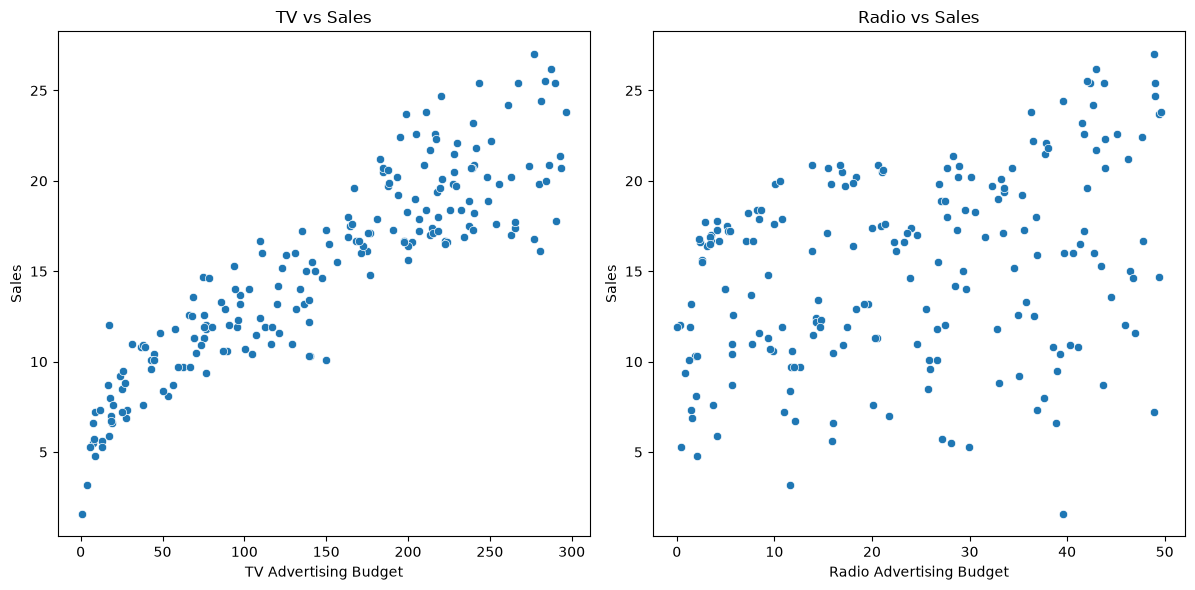

In [20]:
plt.figure(figsize=(18, 6))

# Scatter plot for TV vs Sales
plt.subplot(1, 3, 1)
sns.scatterplot(x=data['TV'], y=data['Sales'])
plt.title('TV vs Sales')
plt.xlabel('TV Advertising Budget')
plt.ylabel('Sales')

# Scatter plot for Radio vs Sales
plt.subplot(1, 3, 2)
sns.scatterplot(x=data['Radio'], y=data['Sales'])
plt.title('Radio vs Sales')
plt.xlabel('Radio Advertising Budget')
plt.ylabel('Sales')

plt.tight_layout()
plt.show()

In [22]:
x.corr()

,TV,Radio,Newspaper
TV,1.000000,0.054809,0.056648
Radio,0.054809,1.000000,0.354104
Newspaper,0.056648,0.354104,1.000000


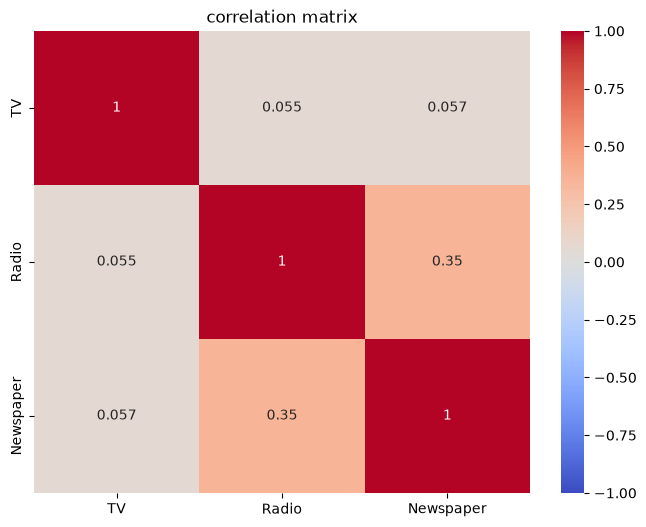

                 TV     Radio  Newspaper
TV         1.000000  0.054809   0.056648
Radio      0.054809  1.000000   0.354104
Newspaper  0.056648  0.354104   1.000000


In [25]:
correlation_matrix = x.corr()

plt.figure(figsize=(8,6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('correlation matrix')
plt.show()

print(correlation_matrix)

### What is VIF (Variance Inflation Factor)?

* VIF measures how much the variance of a regression coefficient is inflated due to multicollinearity among input features.

---

### Why VIF is Important in MLR:

* In Multiple Linear Regression, we use multiple features to predict a target.
* Sometimes, two or more features are strongly correlated with each other (e.g., Education_Level and Years_of_Schooling).
* This creates multicollinearity, which makes it hard for the model to understand which feature is really influencing the output.

### What VIF Tells You:

| VIF Score | Interpretation |
| --- | --- |
| **1** | No multicollinearity (ideal) |
| **1–5** | Moderate multicollinearity (acceptable) |
| **> 5 or 10** | High multicollinearity (potential problem) |

### If You Don't Use VIF:

Your model might still run, but:

* Coefficients will become unstable
* You may get wrong signs or values (e.g., $\beta_1$ is negative when it should be positive)
* Your model might look accurate (high $R^2$) but be misleading

---

### Simple Analogy:

> "VIF is like checking if two ingredients in a recipe are too similar — if they are, you don't really need both."

In [27]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Calculate the VIF for each feature
vif_data = pd.DataFrame()

vif_data["feature"] = x.columns

vif_data["VIF"] = [variance_inflation_factor(x.values, i) for i in range(x.shape[1])]

print("Variance Inflation Factors (VIF):")
print(vif_data)

Variance Inflation Factors (VIF):
     feature       VIF
0         TV  1.004611
1      Radio  1.144952
2  Newspaper  1.145187


### Interpretation of Results:

* **Correlation Matrix**: Helps to visually inspect pairwise correlations. High absolute values (close to $1$ or $-1$) suggest multicollinearity.
* **VIF**:
* $\text{VIF} = 1$: No correlation between the independent variable and the others.
* $1 < \text{VIF} < 5$: Moderate correlation, usually acceptable.
* $\text{VIF} > 5$: Potential multicollinearity problem. Some use a threshold of $10$ instead.

### What to Do If Multicollinearity Is Detected:

1. **Remove Variables**: Consider removing one of the correlated variables.
2. **Combine Variables**: Combine correlated variables into a single predictor.
3. **Regularization Techniques**: Use techniques like Ridge Regression to handle multicollinearity by adding a penalty to the coefficients.

In [28]:
x_train, x_test, y_train,y_test, = train_test_split(x,y, test_size=0.3, random_state=42)
x_train.shape

(140, 3)

In [30]:


y_train.shape

(140,)

In [31]:
x_test.shape, y_test.shape

((60, 3), (60,))

## Create and train the linear regression model

In [34]:
x_train.head()

,TV,Radio,Newspaper
169,284.3,10.6,6.4
97,184.9,21.0,22.0
31,112.9,17.4,38.6
12,23.8,35.1,65.9
35,290.7,4.1,8.5


In [35]:
y_train.head()

169    20.0
97     20.5
31     11.9
12      9.2
35     17.8
Name: Sales, dtype: float64

In [33]:
linear_model = LinearRegression()
linear_model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[0.05,0.1 ,0.01]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](3,)","['TV','Radio','Newspaper']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,4.744
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(3)


# Make predictions

In [37]:
y_test_pred = linear_model.predict(x_test)

In [38]:
y_test_pred 


array([17.15991908, 20.53369503, 23.68914396,  9.5191455 , 21.60736836,
       12.78101318, 21.08636345,  8.76054246, 17.11499951, 16.68789636,
        8.97584663,  8.57645026, 18.33212325,  8.17863567, 12.64605571,
       14.94486946,  8.34939536, 17.83858948, 11.12172174, 20.37740648,
       20.9483297 , 13.04035779, 11.01360656, 22.51142595,  9.40369784,
        7.98591291, 20.86943368, 13.77882255, 10.83407064,  8.00419229,
       15.88597618, 10.7027424 , 20.9521718 , 10.84679243, 21.50720813,
       21.07347295, 12.22673775, 22.85273767, 12.57698182,  6.54597206,
       11.93411853, 15.23490068, 10.07411153,  9.52159696, 17.11786382,
        7.28032677, 10.49404864, 15.24356754, 11.20742176, 11.78392665,
       14.01472163, 14.59884572, 10.82722434,  9.55839415,  9.03749681,
       12.51183313, 10.52551021, 25.01900824,  7.99334943, 15.73916263])

In [39]:
y_test

95     16.9
15     22.4
30     21.4
158     7.3
128    24.7
115    12.6
69     22.3
170     8.4
174    16.5
45     16.1
66     11.0
182     8.7
165    16.9
78      5.3
186    10.3
177    16.7
56      5.5
152    16.6
82     11.3
68     18.9
124    19.7
16     12.5
148    10.9
93     22.2
65     11.3
60      8.1
84     21.7
67     13.4
125    10.6
132     5.7
9      15.6
18     11.3
55     23.7
75      8.7
150    16.1
104    20.7
135    11.6
137    20.8
164    11.9
76      6.9
79     11.0
197    14.8
38     10.1
24      9.7
122    16.6
195     7.6
29     10.5
19     14.6
143    10.4
86     12.0
114    14.6
173    16.7
5       7.2
126     6.6
117     9.4
73     11.0
140    10.9
98     25.4
172     7.6
96     16.7
Name: Sales, dtype: float64

In [42]:
# create DataFrame fortesting data

In [43]:
test_results= pd.DataFrame({
    'Original Sales (test)': y_test,
    'Presdicted Sales (test)': y_test_pred
})

print ('testing data results:')
print(test_results.head())

testing data results:
     Original Sales (test)  Presdicted Sales (test)
95                    16.9                17.159919
15                    22.4                20.533695
30                    21.4                23.689144
158                    7.3                 9.519146
128                   24.7                21.607368


### our model is ready is it accuarate ?

### Non-Linear Model:- How to Know When Multiple Linear Regression (MLR) May Not Work

**Before Applying MLR — Clues from Data Exploration**

---

### 1. Conceptual Clues

#### a. Nature of Variables (Feature-Target Relationship)

* If the real-world relationship is **nonlinear** (not a straight-line effect).
* **Example:**
* **Marketing**: Higher advertising spend doesn't always linearly increase sales (diminishing returns).
* **Healthcare**: Risk of disease vs. age often shows a U-shape.


* **Visual Tip:** Scatter plots that curve, bend, or change direction.

#### b. Correlation Doesn't Tell the Whole Story

* Low or near-zero Pearson correlation but visible non-linear pattern.
* MLR will struggle in these situations.
* **Visual Tip:** Weak correlation but clear pattern in scatter plot $\rightarrow$ suspect non-linearity.

### c. Interaction Effects Present

* If the impact of one feature depends on the level of another feature.
* **Example:**
* Marketing success depends on both **TV and Radio** together, not just independently.


* **MLR Limitation:** MLR cannot capture these unless you **manually add interaction terms**.

---

### d. Forced Feature Engineering

* If you're constantly needing to log-transform, square, or manually adjust variables $\rightarrow$ linear models may not be enough.
* **Action:** Time to explore non-linear methods that naturally capture patterns.

### Summary Table: When to Consider Non-linear Models

| Clue | What to Consider |
| --- | --- |
| **Curved scatter plot** | Polynomial Regression, Decision Trees |
| **Weak correlation + visible pattern** | Decision Tree, Random Forest |
| **Effects depend on feature combinations** | Decision Tree, Gradient Boosting |
| **Performance stalls after adding linear terms** | Non-linear regression or ensemble methods |

### 3 Key Takeaway:

> "Linear regression draws straight lines! But real-life relationships are often curved, stepped, or conditional. Before you ever fit a model, plots and domain knowledge can tell you when it's time to move beyond MLR and explore non-linear algorithms."

---

### Linear vs Non-Linear Regression Demonstration Using Advertising Data

In [44]:
# Step 1: Import Required Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

In [45]:
data = pd.read_csv('advertising_nonlinear.csv')

In [46]:
data.head()

,TV,Radio,Newspaper,Sales,Sales_Nonlinear
0,230.1,37.8,69.2,22.1,5.35
1,44.5,39.3,45.1,10.4,7.20
2,17.2,45.9,69.3,12.0,7.77
3,151.5,41.3,58.5,16.5,9.82
4,180.8,10.8,58.4,17.9,5.66


In [49]:
x = data[['TV','Radio']]
y_linear = data['Sales_Nonlinear']

In [51]:
x.head()

,TV,Radio
0,230.1,37.8
1,44.5,39.3
2,17.2,45.9
3,151.5,41.3
4,180.8,10.8


In [52]:
y_linear.head()

0    5.35
1    7.20
2    7.77
3    9.82
4    5.66
Name: Sales_Nonlinear, dtype: float64

In [53]:
x_train, x_test, y_train, y_test = train_test_split(x, y_linear, test_size=0.2, random_state=42)

In [56]:
lin_reg = LinearRegression()
lin_reg.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](2,)","[-0.01, 0.04]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](2,)","['TV','Radio']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,6.827
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(2)


In [57]:
y_pred_linear = lin_reg.predict(x_test)

In [60]:
r2_lin = r2_score(y_test, y_pred_linear)
rmse_lin = np.sqrt(mean_squared_error(y_test, y_pred_linear))

print("Linear regressison r2:", round(r2_lin, 3))
print("Linear regression Rmse:", round(rmse_lin,3))

Linear regressison r2: 0.269
Linear regression Rmse: 2.144


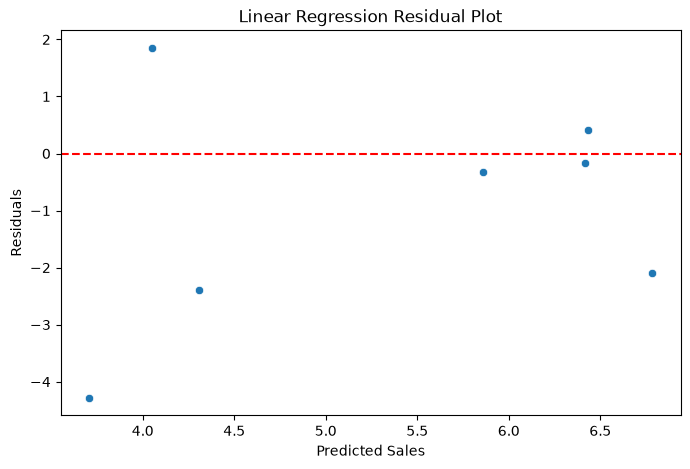

In [61]:
# Plot Residuals for Linear Regression
residuals_lin = y_test - y_pred_linear
plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_pred_linear, y=residuals_lin)
plt.axhline(0, color='red', linestyle='--')
plt.title('Linear Regression Residual Plot')
plt.xlabel('Predicted Sales')
plt.ylabel('Residuals')
plt.show()

In [68]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, include_bias=False)

# Create polynomial features (degree=2) to capture non-linear relationships
x_poly_train = poly.fit_transform(x_train)
x_poly_test = poly.transform(x_test)

# This transforms features X into [X, X², X1*X2, ...] for better model flexibility

# For first sample [2, 3]:
# Original: [x1=2, x2=3]

# Transformed becomes:
# [x1=2, x2=3, x1²=4, x1*x2=6, x2²=9]

#for secound sample [x1=1, x2=4]

#Transformed becomes:

# [x1=1, x2=4, x1^2=1, x1*x2=4, x2^2=16]

# This allows linear regression to model relationships like:

# y = w0*x1 + w1*x2 + w2*x1^2 + w3*x1*x2 + w4*x2^2

# which can capture curved patterns and feature interactions

In [69]:
poly_reg= LinearRegression()


poly_reg.fit(x_poly_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](5,)","[ 0.04, 0.06,-0. ,-0. ,-0. ]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,4.242
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(5)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](5,)","[115953.4 , 9683.72, 2618.33, 64.29, 10.28]"


In [71]:
y_pred_poly = poly_reg.predict(x_poly_test)

In [73]:
r2_poly = r2_score(y_test, y_pred_poly)
rmse_poly = np.sqrt(mean_squared_error(y_test, y_pred_poly))
print("polynomialRegression r2:", round(r2_poly, 3))
print("polynomialRegression RMSE:", round(rmse_poly, 3))



polynomialRegression r2: 0.895
polynomialRegression RMSE: 0.811


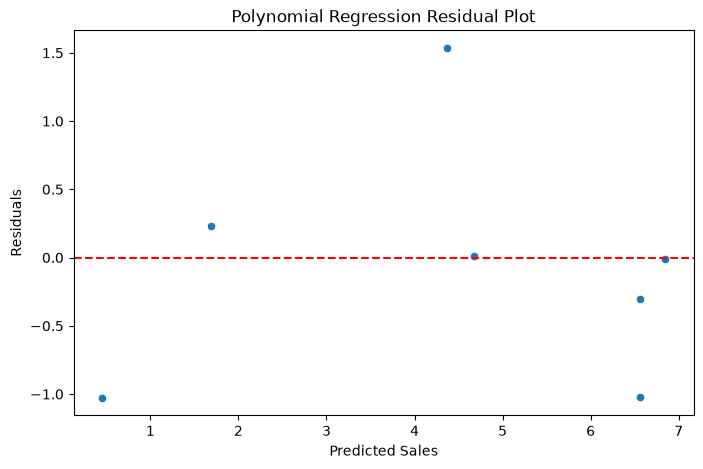

In [74]:
# Plot Residuals for Polynomial Regression
residuals_poly = y_test - y_pred_poly
plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_pred_poly, y=residuals_poly)
plt.axhline(0, color='red', linestyle='--')
plt.title('Polynomial Regression Residual Plot')
plt.xlabel('Predicted Sales')
plt.ylabel('Residuals')
plt.show()

In [75]:
# Range is smaller (±1.0 vs. ±4.0 in the linear plot), meaning better accuracy.

# Step 7: Conclusion Summary
print("\nModel Comparison:")
print(f"Linear Regression → R²: {round(r2_lin, 3)}, RMSE: {round(rmse_lin, 3)}")
print(f"Polynomial Regression → R²: {round(r2_poly, 3)}, RMSE: {round(rmse_poly, 3)}")


Model Comparison:
Linear Regression → R²: 0.269, RMSE: 2.144
Polynomial Regression → R²: 0.895, RMSE: 0.811


In [76]:
# Key Insight:
# If the Polynomial Regression shows higher R² and lower RMSE and more random residuals,
# it indicates a better fit for nonlinear data.